# Dynamical Systems in NumPyro using Dynestyx

Dynestyx connects NumPyro to ODEs, SDEs, hidden Markov models, and other state-space models with partial, irregular, noisy observations. We write a `DynamicalModel` once, then choose handlers for simulation, state inference, and parameter inference. This separation is described in [Waxman et al. (2026), *Dynestyx: A Probabilistic Programming Library for Dynamical Systems*](https://arxiv.org/html/2606.16985v1).

We start with chaotic Lorenz–63 dynamics and learn one parameter, $\rho$, using three approaches:

1. **Joint NUTS with `LatentPathBuilder`:** sample $\rho$ and the initial state. Chaotic sensitivity makes this short joint fit difficult.
2. **Differentiable particle filter (PF):** marginalize the state with particles, then use NUTS or a Normal variational guide. A small bootstrap PF can also struggle with deterministic chaos.
3. **Differentiable ensemble Kalman filter (EnKF):** use a fast Gaussian approximation to state inference with either parameter-inference method.

Next, a nonchaotic **SIR ODE with Poisson observations** shows when joint inference with `LatentPathBuilder` works well. A **stochastic SIR variant** then demonstrates PF + NUTS and reconstruction of the hidden states through filtering and smoothing.

The joint ODE approach also appears in NumPyro's [Lotka–Volterra example](https://num.pyro.ai/en/stable/examples/ode.html) and [multiple-population tutorial](https://num.pyro.ai/en/stable/tutorials/lotka_volterra_multiple.html). For the latter setting in Dynestyx, see [hierarchical inference with `dsx.plate`](gentle_intro/08_hierarchical_inference.ipynb). Our epidemic example is inspired by the [MFIIDD particle MCMC tutorial](https://mfiidd.github.io/mfiidd/sessions/pmcmc.html).

## 1. Installation and setup

Use Python 3.12 or 3.13. This notebook uses the APIs in Dynestyx's current
`main` branch. In a terminal, install the package and start Jupyter:

```sh
uv venv --python 3.12 .venv
uv pip install --python .venv/bin/python \
  "dynestyx @ git+https://github.com/BasisResearch/dynestyx.git@main" jupyter
.venv/bin/jupyter lab
```

When working inside a Dynestyx checkout, use `uv sync --group dev` and
`uv run jupyter lab` instead. Select the environment's Python kernel.
We use **32-bit precision** throughout the numerical calculations.

In [35]:
import diffrax as dfx
import jax
import jax.numpy as jnp
import jax.random as jr
import matplotlib.pyplot as plt
import numpy as np
import numpyro
import numpyro.distributions as dist
from numpyro.distributions.transforms import AffineTransform
from numpyro.handlers import condition
from numpyro.infer import MCMC, NUTS, SVI, Predictive, Trace_ELBO, init_to_value
from numpyro.infer.autoguide import AutoNormal
from numpyro.optim import Adam

import dynestyx as dsx
from dynestyx.discretizers import ODEFlowConfig
from dynestyx.inference.configs.filter import EnKFConfig, PFConfig
from dynestyx.inference.configs.smoother import PFSmootherConfig

jax.config.update("jax_enable_x64", False)

## 2. The mathematical problem

For an ODE with unknown parameters and initial condition, write

$$
\theta\sim p(\theta),\qquad x_0\sim p(x_0),\qquad
\frac{\mathrm dx}{\mathrm dt}=f(x;\theta),\qquad x(0)=x_0,
$$
$$
y_k=Hx(t_k)+\eta_k,\qquad \eta_k\overset{\mathrm{iid}}{\sim}\mathcal N(0,R).
$$

For Lorenz–63, fix $\sigma=10$ and $\beta=8/3$ and learn only $\theta=\rho$:

$$
f(x;\rho)=\begin{pmatrix}
10(x_2-x_1)\\x_1(\rho-x_3)-x_2\\x_1x_2-\frac83x_3
\end{pmatrix},\qquad H=\begin{pmatrix}1&0&0\end{pmatrix},\qquad R=(1).
$$

We assume that $\rho$ lies between 20 and 40. A scaled Beta(2, 2) prior
gently favors the middle of that range and tapers to zero at its ends:


$$
u\sim\operatorname{Beta}(2,2),\quad \rho=20+20u,\qquad
x_0\sim\mathcal N\!\left(
\begin{pmatrix}0\\0\\25\end{pmatrix},100I_3\right).
$$

Observation noise has known standard deviation 1, and there is no process
noise: given $(\rho,x_0)$, the trajectory is deterministic. For generation,
we fix $\rho_*=28$, giving the canonical chaotic parameter set. For
inference, $x_0$ means the unknown state **after burn-in**. The broad Gaussian
is our inference prior for this state; the actual window-start states come
from the burn-in simulation.

## 3. Write the model once

`DynamicalModel` combines the initial-state distribution, ODE, and observation
model. `dsx.sample` connects it to observation times and values, or to
prediction times. Handlers choose how to interpret this same model.

### Read the handler stack from the model outward

A model describes the dynamics and observation process. Handlers decide what to **do** with it. The conceptual order is:

**Model → Discretizer → Inference → Simulator → Evaluation**

| Layer | Purpose |
|---|---|
| `Discretizer` | Turn continuous-time dynamics into transitions between the times needed by a discrete inference algorithm. |
| `Filter`, `Smoother`, or `LatentPathBuilder` | Infer hidden states: marginalize them, condition on the whole record, or expose a joint latent path to NumPyro. Choose the inference handler appropriate to the task. |
| `Simulator` | Generate predictions, optionally conditioned on the state inference performed inside it. |
| `Evaluation` | Score inference outputs. This optional outer layer is outside this tutorial's scope. |

Python writes outer contexts **first**, so a full prediction stack reads `Simulator`, then `Filter`, then `Discretizer`, then the model call. Skip layers you do not need. Already-discrete models do not need a `Discretizer`; direct ODE simulation and `LatentPathBuilder` can use their own solver. This notebook uses **Discretizer + Cuthbert** for filtering and smoothing.

The following are **illustrative patterns only**, displayed as text rather than executed cells. Assume `model` calls `dsx.sample` and the configuration objects have been chosen for that model.

**Marginal likelihood for NUTS or SVI.** The filter integrates over states; NumPyro handles the parameter sites in `model`.

```python
def marginal_model(obs_times, obs_values):
    with dsx.Filter(filter_config):
        with dsx.Discretizer(discretizer_config):
            return model(obs_times=obs_times, obs_values=obs_values)
# Pass marginal_model to NUTS or SVI.
```

**Filter, then forecast.** Condition on observations up to a cutoff and propagate the uncertain final filtered state into the future. `Predictive` can also supply posterior parameter draws.

```python
def forecast_model(obs_times, obs_values, predict_times):
    with dsx.Simulator(n_simulations=8):
        with dsx.Filter(filter_config):
            with dsx.Discretizer(discretizer_config):
                return model(obs_times=obs_times, obs_values=obs_values,
                             predict_times=predict_times)
# Predictive(forecast_model, posterior_samples=parameter_draws)(
#     key, obs_times=past_times, obs_values=past_values,
#     predict_times=future_times)
```

**Smooth a historical record.** Use all observations, including those after a state of interest, to reconstruct past states. `Smoother` can record its state distributions or particles directly; add an outer `Simulator` when requesting predictive draws from those results.

```python
def smoothing_model(obs_times, obs_values):
    with dsx.Smoother(smoother_config):
        with dsx.Discretizer(discretizer_config):
            return model(obs_times=obs_times, obs_values=obs_values)
# Predictive can collect the smoothed-state sites for each parameter draw.
```

**Joint ODE inference.** Expose the initial condition as a NumPyro latent variable and solve the rest of the trajectory. `LatentPathBuilder` uses its ODE solver to integrate the trajectory directly here.

```python
def joint_model(obs_times, obs_values):
    with dsx.LatentPathBuilder(ode_simulator_config=ode_config):
        return model(obs_times=obs_times, obs_values=obs_values)
# Pass joint_model to NUTS to sample parameters and the initial state together.
```

`Predictive` and `MCMC` are NumPyro drivers around these interpreted models. A `Filter` is state inference inside one model evaluation; NUTS or SVI performs parameter inference outside it.

In [36]:
def l63_model(obs_times=None, obs_values=None, predict_times=None):
    # A regular NumPyro sample site is the only unknown system parameter.
    rho = numpyro.sample(
        "rho",
        dist.TransformedDistribution(
            dist.Beta(2.0, 2.0),
            # Map the Beta's [0, 1] support to rho in [20, 40].
            AffineTransform(20.0, 20.0, domain=dist.constraints.unit_interval),
        ),
    )

    def drift(x, u, t):
        # This autonomous ODE does not use controls u or time t explicitly.
        return jnp.array(
            [
                10.0 * (x[1] - x[0]),
                x[0] * (rho - x[2]) - x[1],
                x[0] * x[1] - (8.0 / 3.0) * x[2],
            ]
        )

    dynamics = dsx.DynamicalModel(
        # The inference handler will integrate out or sample this state.
        initial_condition=dist.MultivariateNormal(
            jnp.array([0.0, 0.0, 25.0]), covariance_matrix=100.0 * jnp.eye(3)
        ),
        state_evolution=dsx.ContinuousTimeStateEvolution(drift=drift),
        # H selects x1. R is the observation covariance.
        observation_model=dsx.LinearGaussianObservation(
            H=jnp.array([[1.0, 0.0, 0.0]]), R=jnp.array([[1.0]])
        ),
    )
    return dsx.sample(
        "l63",
        dynamics,
        obs_times=obs_times,
        obs_values=obs_values,
        predict_times=predict_times,
    )

## 4. Simulate two trajectories at irregular observation times

Fix the canonical chaotic parameters $(\sigma,\rho,\beta)=(10,28,8/3)$. `Predictive(num_samples=2)` independently samples initial states and observation noise. Each trajectory runs for **100 burn-in + 10 retained time units**.

Sample **38 observation times over 0–5** for training and **30 times over 0–4** for the independent evaluation trajectory, including each window's endpoints. There are no missing-value placeholders: we pass only actual measurements to inference. A separate regular grid is used to display the underlying states.

`Simulator` uses fixed Tsit5 steps of 0.01 for generation; inference uses 0.02. Prediction times select saved output, rather than the solver's internal steps.

In [37]:
BURN_IN, TRAIN_END, FILTER_END, FINAL_TIME = 100.0, 5.0, 4.0, 10.0
TRUE_RHO = 28.0

train_times = jnp.concatenate(
    [
        jnp.array([0.0]),
        jnp.sort(jr.uniform(jr.PRNGKey(4), (36,), minval=0.05, maxval=4.95)),
        jnp.array([TRAIN_END]),
    ]
)
filter_times = jnp.concatenate(
    [
        jnp.array([0.0]),
        jnp.sort(jr.uniform(jr.PRNGKey(5), (28,), minval=0.05, maxval=3.95)),
        jnp.array([FILTER_END]),
    ]
)
all_times = jnp.linspace(0.0, FINAL_TIME, 101)
simulation_times = jnp.unique(
    jnp.concatenate(
        [
            jnp.array([0.0]),
            BURN_IN + all_times,
            BURN_IN + train_times,
            BURN_IN + filter_times,
        ]
    )
)

with dsx.Simulator(simulator_config=dsx.ODESimulatorConfig(dt0=0.01)):
    synthetic = Predictive(
        condition(l63_model, data={"rho": TRUE_RHO}),
        num_samples=2,
    )(jr.PRNGKey(8), predict_times=simulation_times)

`Predictive` collects NumPyro sites, including those added by `Simulator`. Inspect their names and shapes, then select the arrays we need. State and observation axes are `(Predictive draw, simulator replicate, time, coordinate)`. `l63_x_0` is the **pre-burn-in** initial state; it is distinct from the initial state of our retained inference window. The `rho` site contains the two conditioned values, both 28.

In [38]:
for name, value in synthetic.items():
    print(f"{name}: {value.shape}")

true_rho = synthetic["rho"]
pre_burn_initial_states = synthetic["l63_x_0"][:, 0]
saved_times = synthetic["l63_times"][0, 0]
plot_indices = jnp.searchsorted(saved_times, BURN_IN + all_times)
train_indices = jnp.searchsorted(saved_times, BURN_IN + train_times)
filter_indices = jnp.searchsorted(saved_times, BURN_IN + filter_times)

states = synthetic["l63_states"][:, 0, plot_indices]
train_values = synthetic["l63_observations"][0, 0, train_indices]
filter_values = synthetic["l63_observations"][1, 0, filter_indices]
# Rebase the saved float32 times to the start of the retained window.
train_times = saved_times[train_indices] - BURN_IN
filter_times = saved_times[filter_indices] - BURN_IN
all_times = saved_times[plot_indices] - BURN_IN
train_data = {"obs_times": train_times, "obs_values": train_values}
evaluation_data = {"obs_times": filter_times, "obs_values": filter_values}
train_plot_times, train_states = all_times[:51], states[0, :51]
evaluation_times, evaluation_states = all_times, states[1]
forecast_times = all_times[40:]  # Cutoff state at time 4, then six forecast units.

l63_obs_times: (2, 1, 166)
l63_observations: (2, 1, 166, 1)
l63_states: (2, 1, 166, 3)
l63_times: (2, 1, 166)
l63_x_0: (2, 1, 3)
rho: (2,)


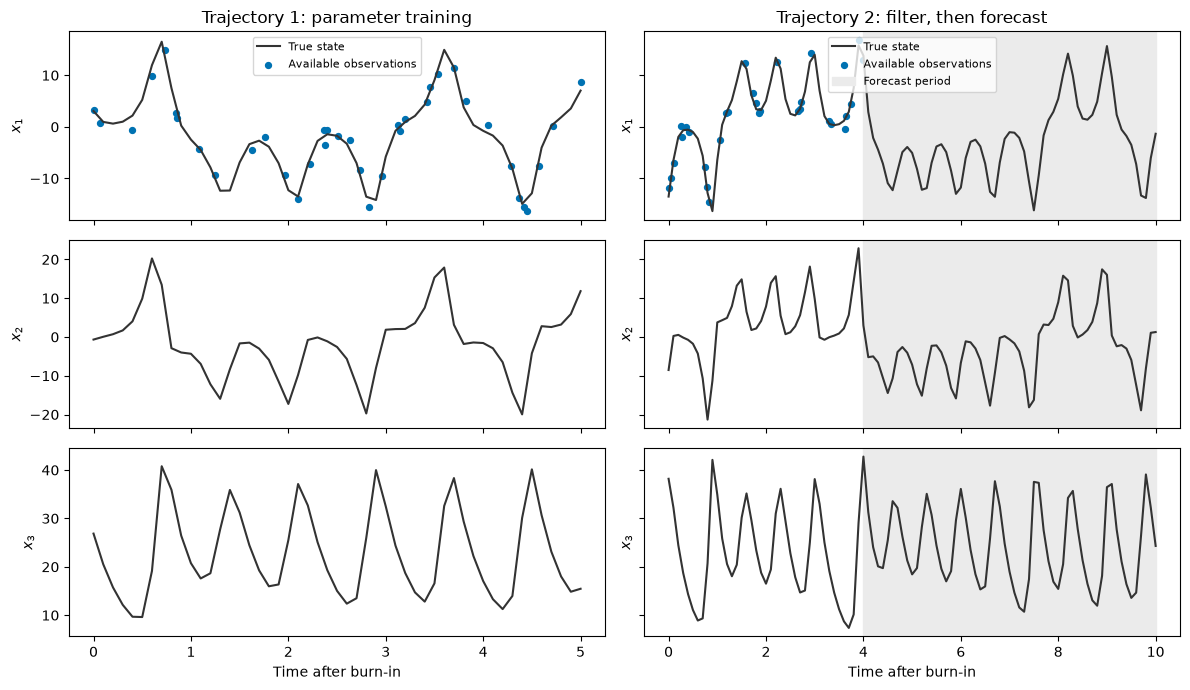

In [39]:
fig, axes = plt.subplots(3, 2, figsize=(12, 7), sharex="col", sharey="row")
for column, (times, truth, obs_times, values) in enumerate(
    (
        (train_plot_times, train_states, train_times, train_values),
        (evaluation_times, evaluation_states, filter_times, filter_values),
    )
):
    for component, ax in enumerate(axes[:, column]):
        ax.plot(times, truth[:, component], color="0.2", label="True state")
        if component == 0:
            ax.scatter(
                obs_times,
                values[:, 0],
                s=18,
                color="#0072B2",
                label="Available observations",
            )
        if column == 1:
            ax.axvspan(FILTER_END, FINAL_TIME, color="0.92", label="Forecast period")
        ax.set_ylabel(f"$x_{component + 1}$")
    axes[-1, column].set_xlabel("Time after burn-in")
axes[0, 0].set_title("Trajectory 1: parameter training")
axes[0, 1].set_title("Trajectory 2: filter, then forecast")
axes[0, 0].legend(fontsize=8)
axes[0, 1].legend(fontsize=8)
fig.tight_layout()
plt.show()

## 5. Joint inference or state marginalization?

Write $\Phi_\rho(t;x_0)$ for the ODE solution and $Y=(y_0,\ldots,y_K)$ for the irregularly sampled training data. We want $p(\rho\mid Y)\propto p(\rho)p(Y\mid\rho)$.

**Joint inference** samples the initial condition explicitly:

$$p(\rho,x_0\mid Y)\propto p(\rho)p(x_0)
\prod_{k=0}^K\mathcal N\!\left(y_k;H\Phi_\rho(t_k;x_0),R\right).$$

**State marginalization** integrates out that initial condition, or equivalently computes sequential predictive likelihoods:

$$p(Y\mid\rho)=\int p(x_0)\prod_{k=0}^K p(y_k\mid\Phi_\rho(t_k;x_0))\,\mathrm dx_0
=\prod_{k=0}^K\int p(y_k\mid x_k)\,p(x_k\mid Y_{<k},\rho)\,\mathrm dx_k.$$

`LatentPathBuilder` constructs the joint likelihood. A filter approximates the second. Dynestyx offers Kalman, extended Kalman, unscented Kalman, ensemble Kalman, and particle filters.

### Joint NUTS: sensitivity to the initial state

For this ODE, `LatentPathBuilder` exposes four coordinates for NUTS to sample: $\rho$ and $x_0\in\mathbb R^3$. Later states are deterministic. As the window grows, chaotic sensitivity can produce a sharply curved, multimodal joint posterior; this is a computational difficulty, not a claim that every chaotic inverse problem is statistically unidentifiable.

Use default initialization for $\rho$. For $x_0$, supply a rough guess from the first observation, without using the true state. This deliberately short run has 100 warmup steps and 100 draws. Inspect its diagnostics and reconstructed trajectory before trusting its narrow parameter histograms.

In [40]:
path_solver = dsx.ODESimulatorConfig(
    dt0=0.02,
    max_steps=512,
    adjoint=dfx.DirectAdjoint(),
)


def path_model(obs_times=None, obs_values=None, predict_times=None):
    with dsx.LatentPathBuilder(ode_simulator_config=path_solver):
        return l63_model(obs_times, obs_values, predict_times)


first_y = train_values[0, 0]
path_mcmc = MCMC(
    NUTS(
        path_model,
        init_strategy=init_to_value(
            values={
                "l63_state_path_params": jnp.array([[first_y, first_y, 25.0]]),
            }
        ),
        dense_mass=True,
        target_accept_prob=0.9,
        max_tree_depth=6,
    ),
    num_warmup=100,
    num_samples=100,
)
path_mcmc.run(jr.PRNGKey(43), **train_data)
path_samples = path_mcmc.get_samples()
path_mcmc.print_summary()

sample: 100%|██████████| 200/200 [00:22<00:00,  8.99it/s, 63 steps of size 3.18e-03. acc. prob=0.96]


                                mean       std    median      5.0%     95.0%     n_eff     r_hat
l63_state_path_params[0,0]      3.20      0.00      3.20      3.19      3.20      5.55      1.15
l63_state_path_params[0,1]      3.20      0.00      3.20      3.20      3.21      4.01      1.71
l63_state_path_params[0,2]     25.00      0.00     25.00     24.99     25.00      3.91      2.10
                       rho     31.05      0.00     31.05     31.05     31.06      7.98      1.14

Number of divergences: 0


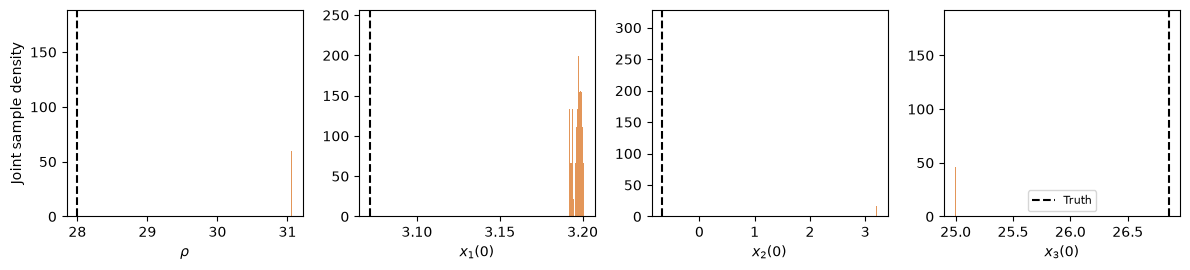

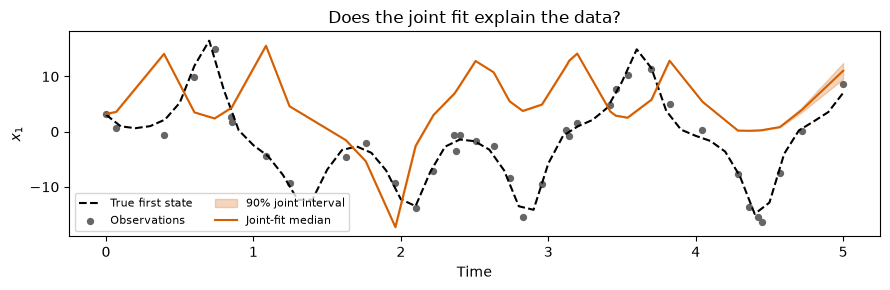

In [41]:
fig, axes = plt.subplots(1, 4, figsize=(12, 2.8))
values = [path_samples["rho"], *path_samples["l63_state_path_params"][:, 0].T]
truths = [TRUE_RHO, *train_states[0]]
labels = [r"$\rho$", r"$x_1(0)$", r"$x_2(0)$", r"$x_3(0)$"]
for ax, draws, truth, label in zip(axes, values, truths, labels):
    ax.hist(draws, bins=20, density=True, color="#D55E00", alpha=0.65)
    ax.axvline(truth, color="black", ls="--", label="Truth")
    ax.set_xlabel(label)
axes[0].set_ylabel("Joint sample density")
axes[-1].legend(fontsize=8)
fig.tight_layout()
plt.show()

# LatentPathBuilder records the path's own grid, including its initial-state entry.
path_times = path_samples["l63_state_path_times"][0]
low, middle, high = jnp.quantile(
    path_samples["l63_state_path"][:, :, 0],
    jnp.array([0.05, 0.5, 0.95]),
    axis=0,
)
fig, ax = plt.subplots(figsize=(9, 3))
ax.plot(train_plot_times, train_states[:, 0], "k--", label="True first state")
ax.scatter(train_times, train_values[:, 0], s=18, color="0.4", label="Observations")
ax.fill_between(
    path_times, low, high, color="#D55E00", alpha=0.25, label="90% joint interval"
)
ax.plot(path_times, middle, color="#D55E00", label="Joint-fit median")
ax.set(xlabel="Time", ylabel=r"$x_1$", title="Does the joint fit explain the data?")
ax.legend(fontsize=8, ncol=2)
fig.tight_layout()
plt.show()

In the recorded run, the joint NUTS fit using `LatentPathBuilder` stays near $\rho=31.05$ instead of 28, with effective sample sizes of roughly 4–8 and split $\hat R$ as high as 2.10. The initial-state samples barely move, and the reconstructed first component misses much of the data. There are no reported divergences, which alone does **not** establish convergence. These are samples from a failed short fit, not a reliable recovered posterior.

## 6. Combine parameter inference with a filter

`Discretizer(ODEFlowConfig(...))` solves the ODE between observation times; `Filter` provides an approximate marginal likelihood. Both handlers wrap the **same** `l63_model`.

A bootstrap PF propagates weighted particles and resamples them. Classical particle MCMC uses this likelihood estimator within an extended-state algorithm ([Andrieu, Doucet, and Holenstein, 2010](https://doi.org/10.1111/j.1467-9868.2009.00736.x)). Dynestyx's differentiable resampling allows gradient-based inference ([Ścibior and Wood, 2021](https://arxiv.org/abs/2106.10314)). Here we fix the filter's random seed and use a finite-particle approximate target; this is **not exact pseudo-marginal PMMH**, which also samples the filter randomness. Differentiability does not eliminate particle depletion or guarantee an easy NUTS target.

The EnKF instead makes Gaussian approximations. See [Drovandi et al. (2022)](https://doi.org/10.1214/20-BA1251) for ensemble MCMC and [Chen, Sanz-Alonso, and Willett (2022)](https://doi.org/10.1137/21M1434477) for autodifferentiable EnKFs. Combining these state estimators with NumPyro parameter algorithms is the design illustrated by the [Dynestyx paper](https://arxiv.org/html/2606.16985v1).

We use the default EnKF (30 members and fixed randomness), and 128 PF particles with a fixed seed. Bounded solver steps and short NUTS trees keep this comparison small. The normal guide is `AutoNormal`: it is Gaussian in **unconstrained parameter coordinates**, then transformed into $20<\rho<40$. NUTS uses 250 warmup steps and 250 draws; SVI uses 1,000 updates. All four fits use default parameter initialization.

In [42]:
flow_config = ODEFlowConfig(
    simulator_config=dsx.ODESimulatorConfig(dt0=0.02),
    jitter_scale=1e-6,
)
filter_configs = {
    "PF": PFConfig(n_particles=128),
    "EnKF": EnKFConfig(),
}


def filtered_model(
    obs_times=None, obs_values=None, predict_times=None, filter_config=None
):
    with dsx.Filter(filter_config), dsx.Discretizer(flow_config):
        return l63_model(obs_times, obs_values, predict_times)


posterior_draws, fits = {}, {}
# Outer inference: parameters. Inner inference: the hidden dynamical state.
for inference in ("NUTS", "SVI Normal"):
    for filter_name, filter_config in filter_configs.items():
        fit_data = {**train_data, "filter_config": filter_config}
        if inference == "NUTS":
            fit = MCMC(
                NUTS(filtered_model, target_accept_prob=0.9, max_tree_depth=4),
                num_warmup=250,
                num_samples=250,
            )
            fit.run(jr.PRNGKey(42), **fit_data)
            draws = fit.get_samples()
        else:
            guide = AutoNormal(filtered_model)
            svi = SVI(filtered_model, guide, Adam(0.01), Trace_ELBO())
            fit = svi.run(jr.PRNGKey(42), 1000, **fit_data, progress_bar=True)
            draws = guide.sample_posterior(
                jr.PRNGKey(45), fit.params, sample_shape=(250,)
            )
        posterior_draws[filter_name, inference] = {"rho": draws["rho"]}
        fits[filter_name, inference] = fit

100%|██████████| 1000/1000 [00:11<00:00, 88.31it/s, init loss: 86.7127, avg. loss [951-1000]: 77.5311]


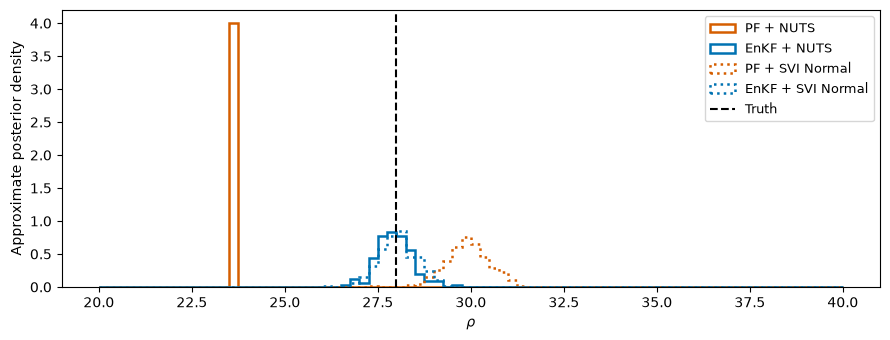

In [43]:
fig, ax = plt.subplots(figsize=(9, 3.5))
for (filter_name, inference), draws in posterior_draws.items():
    ax.hist(
        draws["rho"],
        bins=np.linspace(20, 40, 81),
        density=True,
        histtype="step",
        linewidth=1.8,
        color={"EnKF": "#0072B2", "PF": "#D55E00"}[filter_name],
        linestyle={"NUTS": "-", "SVI Normal": ":"}[inference],
        label=f"{filter_name} + {inference}",
    )
ax.axvline(TRUE_RHO, color="black", ls="--", label="Truth")
ax.set(xlabel=r"$\rho$", ylabel="Approximate posterior density")
ax.legend(fontsize=9)
fig.tight_layout()
plt.show()

In this run, EnKF + NUTS and EnKF + SVI concentrate near the generating value 28. PF + NUTS instead stays near 23.6, while PF + SVI settles near 32.3. The PF curves are failed recoveries, despite looking precise.

These four fits illustrate two different approximations: **how states are marginalized**, and **how the parameter posterior is explored or approximated**. Deterministic chaotic evolution can leave a small bootstrap PF with very few distinct surviving trajectories, even in three state dimensions. Increasing particle counts and checking seeds is essential before treating such a fit as a reference posterior.

## 7. Filter, then forecast an independent trajectory

Use the EnKF + NUTS parameter draws for trajectory 2. Filter its observations through time 4, then forecast the remaining six units:

$$p_{\rm transfer}(x(t))=\iint p(x(t)\mid x_4,\rho)\,
\widehat p(x_4\mid Y_{\rm eval,\leq4},\rho)\,
\widehat p(\rho\mid Y_{\rm train})\,\mathrm dx_4\,\mathrm d\rho.$$

The evaluation observations update the new trajectory's state; they do not refit or reweight the training parameter posterior. `Predictive` propagates **50 parameter draws**, with **eight conditional state rollouts** each. The intervals include both parameter and filtered-state uncertainty.

In [44]:
def forecast_model(obs_times=None, obs_values=None, predict_times=None):
    with (
        dsx.Simulator(n_simulations=8),
        dsx.Filter(filter_configs["EnKF"]),
        dsx.Discretizer(flow_config),
    ):
        return l63_model(obs_times, obs_values, predict_times)


full_predictive = Predictive(
    forecast_model,
    posterior_samples={"rho": posterior_draws["EnKF", "NUTS"]["rho"][::5]},
    return_sites=("l63_predicted_states",),
)(jr.PRNGKey(70), **evaluation_data, predict_times=forecast_times)

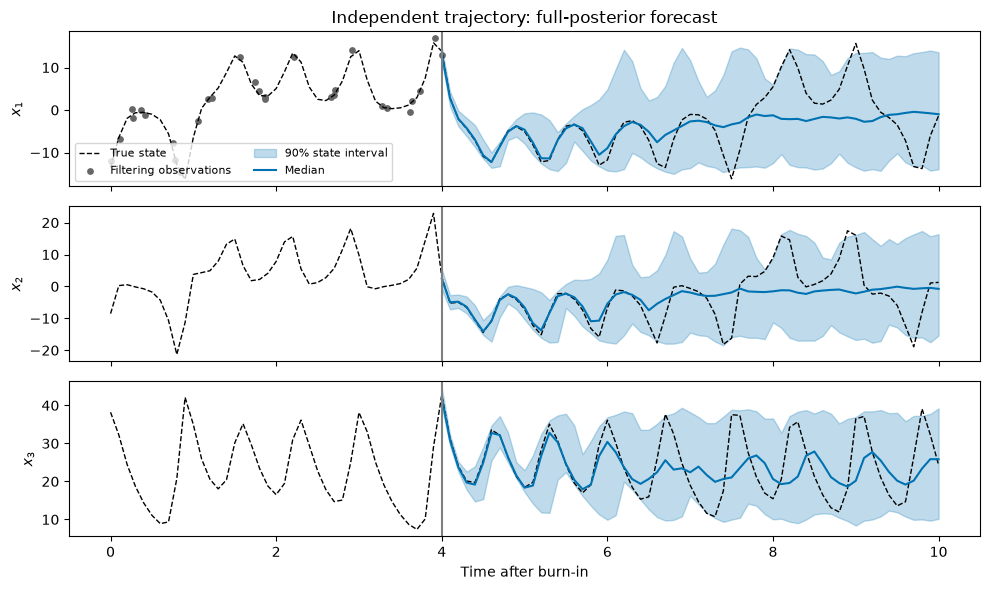

In [45]:
forecast_draws = full_predictive["l63_predicted_states"].reshape(
    -1, len(forecast_times), 3
)
lower, median, upper = jnp.quantile(
    forecast_draws, jnp.array([0.05, 0.5, 0.95]), axis=0
)
fig, axes = plt.subplots(3, 1, figsize=(10, 6), sharex=True)
for component, ax in enumerate(axes):
    ax.plot(
        evaluation_times,
        evaluation_states[:, component],
        "k--",
        lw=1,
        label="True state",
    )
    if component == 0:
        ax.scatter(
            filter_times,
            filter_values[:, 0],
            s=15,
            color="0.4",
            label="Filtering observations",
        )
    ax.fill_between(
        forecast_times,
        lower[:, component],
        upper[:, component],
        color="#0072B2",
        alpha=0.25,
        label="90% state interval",
    )
    ax.plot(forecast_times, median[:, component], color="#0072B2", label="Median")
    ax.axvline(FILTER_END, color="0.5")
    ax.set_ylabel(f"$x_{component + 1}$")
axes[0].set_title("Independent trajectory: full-posterior forecast")
axes[0].legend(fontsize=8, ncol=2)
axes[-1].set_xlabel("Time after burn-in")
fig.tight_layout()
plt.show()

Far into a chaotic forecast, the median can average across very different possible trajectories. These are pointwise state intervals, not simultaneous trajectory bands or intervals for noisy future observations.

## 8. A nonchaotic counterexample: SIR with Poisson observations

Consider a small epidemic. We use a **deterministic SIR ODE** with uncertain
initial conditions and Poisson measurement noise. Let $s+i+r=1$ be population fractions:

$$
\dot s=-\beta si,\qquad \dot i=\beta si-\gamma i,\qquad \dot r=\gamma i,
\qquad y_k\sim\operatorname{Poisson}(N i(t_k)).
$$

Fix $N=500$ and $\gamma=0.1$, and learn $\beta\sim\operatorname{Uniform}(0.2,0.6)$.
The prior $(s_0,i_0,r_0)\sim\operatorname{Dirichlet}(97,2,1)$ keeps the initial
fractions positive and summing to one. Here the observations span both the
rise and decline of the outbreak, and there is no chaotic amplification of
initial-state errors.

In [46]:
SIR_POPULATION = 500
SIR_GAMMA = 0.1
SIR_TRUE_BETA = 0.4


def sir_model(obs_times=None, obs_values=None, predict_times=None):
    beta = numpyro.sample("beta", dist.Uniform(0.2, 0.6))

    def drift(x, u, t):
        s, i, r = x
        infections, recoveries = beta * s * i, SIR_GAMMA * i
        return jnp.array([-infections, infections - recoveries, recoveries])

    dynamics = dsx.DynamicalModel(
        initial_condition=dist.Dirichlet(jnp.array([97.0, 2.0, 1.0])),
        state_evolution=dsx.ContinuousTimeStateEvolution(drift=drift),
        # A distribution-valued observation model also supports count data.
        observation_model=lambda x, u, t: dist.Poisson(SIR_POPULATION * x[1:2]),
    )
    return dsx.sample(
        "sir",
        dynamics,
        obs_times=obs_times,
        obs_values=obs_values,
        predict_times=predict_times,
    )

In [47]:
sir_times = jnp.arange(0.0, 42.0, 2.0)  # 21 measurements over 40 days.
sir_solver = dsx.ODESimulatorConfig(dt0=0.5)

with dsx.Simulator(simulator_config=sir_solver):
    sir_synthetic = Predictive(
        condition(sir_model, data={"beta": SIR_TRUE_BETA}),
        num_samples=1,
        return_sites=("sir_states", "sir_observations"),
    )(jr.PRNGKey(81), predict_times=sir_times)

sir_states = sir_synthetic["sir_states"][0, 0]
sir_values = sir_synthetic["sir_observations"][0, 0]
sir_data = {"obs_times": sir_times, "obs_values": sir_values}

`LatentPathBuilder` samples $p(\beta,x_0\mid Y)$ directly. There are only
**three free coordinates**: $\beta$ and two initial fractions (the third is
determined by their sum). Use 150 warmup steps, 150 draws, and default NUTS
initialization.

We could also marginalize the initial state with a particle filter and run
particle MCMC, but that is overkill here: this nonchaotic ODE makes the small
joint fit straightforward.

In [48]:
def sir_path_model(obs_times=None, obs_values=None):
    with dsx.LatentPathBuilder(ode_simulator_config=sir_solver):
        return sir_model(obs_times, obs_values)


sir_path_mcmc = MCMC(NUTS(sir_path_model), num_warmup=150, num_samples=150)
sir_path_mcmc.run(jr.PRNGKey(83), **sir_data)
sir_path_samples = sir_path_mcmc.get_samples()
sir_path_mcmc.print_summary()

sample: 100%|██████████| 300/300 [00:04<00:00, 70.49it/s, 31 steps of size 2.37e-01. acc. prob=0.91] 


                                mean       std    median      5.0%     95.0%     n_eff     r_hat
                      beta      0.40      0.01      0.40      0.38      0.42     78.13      1.00
sir_state_path_params[0,0]      0.97      0.01      0.97      0.96      0.98     32.98      1.08
sir_state_path_params[0,1]      0.02      0.00      0.02      0.02      0.03     91.37      1.02
sir_state_path_params[0,2]      0.01      0.01      0.01      0.00      0.02     35.61      1.05

Number of divergences: 0


`LatentPathBuilder` records the state paths from the joint fit, giving posterior draws of all three population fractions. Plot their pointwise 90% credible intervals in population units; only the infected compartment was measured. The observations are Poisson counts, so they need not lie inside the latent-state interval.

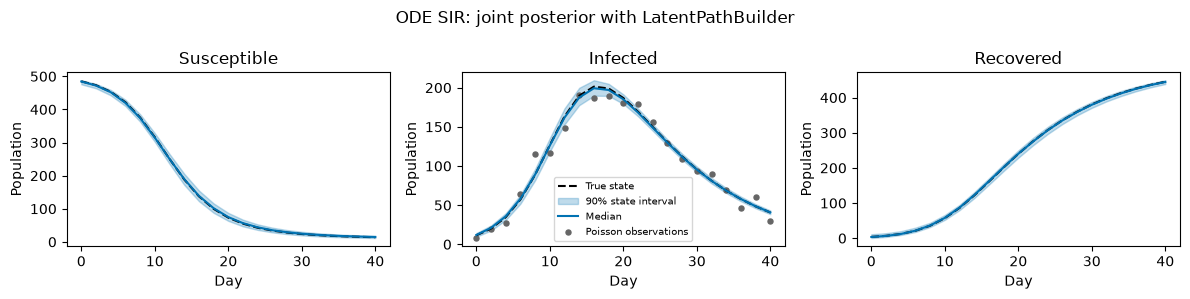

In [49]:
def plot_sir_states(
    times, state_draws, truth_times, truth, obs_times, obs_values, title
):
    """Plot state samples with shape (draw, time, three compartments)."""
    low, middle, high = np.quantile(
        SIR_POPULATION * np.asarray(state_draws),
        [0.05, 0.5, 0.95],
        axis=0,
    )
    fig, axes = plt.subplots(1, 3, figsize=(12, 3), sharex=True)
    for component, (ax, label) in enumerate(
        zip(axes, ("Susceptible", "Infected", "Recovered"))
    ):
        ax.plot(
            truth_times, SIR_POPULATION * truth[:, component], "k--", label="True state"
        )
        ax.fill_between(
            times,
            low[:, component],
            high[:, component],
            color="#0072B2",
            alpha=0.25,
            label="90% state interval",
        )
        ax.plot(times, middle[:, component], color="#0072B2", label="Median")
        if component == 1:
            ax.scatter(
                obs_times,
                obs_values[:, 0],
                s=13,
                color="0.4",
                label="Poisson observations",
            )
        ax.set(title=label, xlabel="Day", ylabel="Population")
    axes[1].legend(fontsize=7)
    fig.suptitle(title)
    fig.tight_layout()
    plt.show()


plot_sir_states(
    sir_path_samples["sir_state_path_times"][0],
    sir_path_samples["sir_state_path"],
    sir_times,
    sir_states,
    sir_times,
    sir_values,
    "ODE SIR: joint posterior with LatentPathBuilder",
)

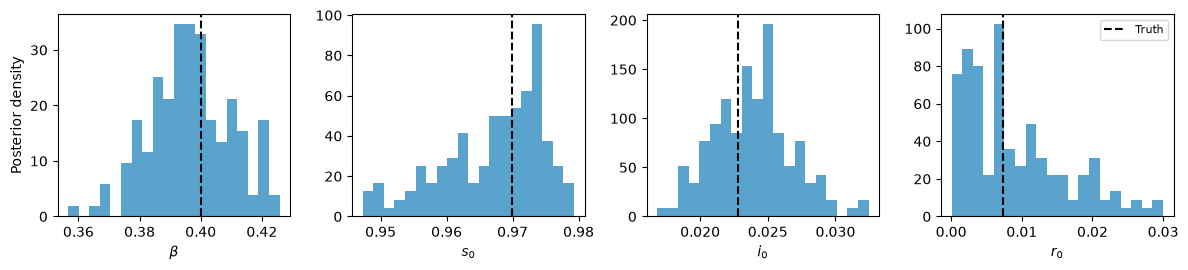

In [50]:
fig, axes = plt.subplots(1, 4, figsize=(12, 2.8))
values = [sir_path_samples["beta"], *sir_path_samples["sir_state_path_params"][:, 0].T]
truths = [SIR_TRUE_BETA, *sir_states[0]]
labels = [r"$\beta$", r"$s_0$", r"$i_0$", r"$r_0$"]
for ax, draws, truth, label in zip(axes, values, truths, labels):
    ax.hist(draws, bins=20, density=True, color="#0072B2", alpha=0.65)
    ax.axvline(truth, color="black", ls="--", label="Truth")
    ax.set_xlabel(label)
axes[0].set_ylabel("Posterior density")
axes[-1].legend(fontsize=8)
fig.tight_layout()
plt.show()

Here the diagnostics and recovered trajectories support the joint fit. With known recovery rate and observations spanning the outbreak, joint inference with `LatentPathBuilder` is much easier in this nonchaotic example than in Lorenz–63. Nonchaoticity alone does not guarantee identifiability: the observation model, time window, and priors still matter.

## 9. Stochastic epidemics: a differentiable particle filter with NUTS

We can also model randomness **in the epidemic itself**. The
[MFIIDD particle MCMC example](https://mfiidd.github.io/mfiidd/sessions/pmcmc.html)
does this with an integer-valued compartment model and **particle marginal
Metropolis–Hastings (PMMH)**; its particle filter is not autodifferentiable,
so it does not use NUTS. Here we use a small continuous SIR variant with
process noise and a **differentiable PF + NUTS**.

To keep fractions positive and summing to one, write
$z=(\log(s/r),\log(i/r))$ and $(s,i,r)=\operatorname{softmax}(z_1,z_2,0)$.
Add independent Brownian noise in these coordinates:

$$
\mathrm dz=\begin{pmatrix}-\beta i-\gamma i/r\\
\beta s-\gamma-\gamma i/r\end{pmatrix}\mathrm dt
+0.05\,\mathrm dW_t,\qquad
z_0\sim\mathcal N\!\left(\begin{pmatrix}\log97\\\log2\end{pmatrix},0.2^2I_2\right).
$$

With zero process noise, this gives the SIR ODE. Keep the same prior on
$\beta$, known $\gamma=0.1$, and Poisson observations of $Ni(t)$.
`Discretizer()` defaults to Euler–Maruyama for this SDE; we simulate and fit
the same daily-step approximation.

In [65]:
def sir_fractions(z):
    return jax.nn.softmax(
        jnp.concatenate([z, jnp.zeros_like(z[..., :1])], axis=-1), axis=-1
    )


def stochastic_sir_model(obs_times=None, obs_values=None, predict_times=None):
    beta = numpyro.sample("beta", dist.Uniform(0.2, 0.6))

    def drift(x, u, t):
        s, i, r = sir_fractions(x)
        return jnp.array(
            [-beta * i - SIR_GAMMA * i / r, beta * s - SIR_GAMMA - SIR_GAMMA * i / r]
        )

    dynamics = dsx.DynamicalModel(
        initial_condition=dist.Normal(jnp.log(jnp.array([97.0, 2.0])), 0.2).to_event(1),
        state_evolution=dsx.ContinuousTimeStateEvolution(
            drift=drift, diffusion=dsx.ScalarDiffusion(0.1, bm_dim=2)
        ),
        observation_model=lambda x, u, t: dist.Poisson(
            SIR_POPULATION * sir_fractions(x)[1:2]
        ),
    )
    return dsx.sample(
        "stochastic_sir",
        dynamics,
        obs_times=obs_times,
        obs_values=obs_values,
        predict_times=predict_times,
    )

The particle filter now marginalizes the **whole stochastic state path**.
Its default resampling uses a stop-gradient score estimator, allowing us to
pass the filtered model to NUTS. A fixed filter seed makes each likelihood
evaluation repeatable. This targets a finite-particle approximation to the
posterior; exact pseudo-marginal PMMH also samples the filter's randomness.

In [66]:
stochastic_times = jnp.arange(41, dtype=jnp.float32)
with dsx.Simulator(), dsx.Discretizer():
    stochastic_synthetic = Predictive(
        condition(stochastic_sir_model, data={"beta": SIR_TRUE_BETA}),
        num_samples=1,
        return_sites=("stochastic_sir_states", "stochastic_sir_observations"),
    )(jr.PRNGKey(90), predict_times=stochastic_times)

stochastic_states = stochastic_synthetic["stochastic_sir_states"][0, 0]
stochastic_values = stochastic_synthetic["stochastic_sir_observations"][0, 0]
stochastic_data = {"obs_times": stochastic_times, "obs_values": stochastic_values}
stochastic_pf_config = PFConfig(n_particles=512, crn_seed=jr.PRNGKey(0))


def stochastic_pf_model(obs_times=None, obs_values=None):
    with dsx.Filter(stochastic_pf_config), dsx.Discretizer():
        return stochastic_sir_model(obs_times, obs_values)


stochastic_mcmc = MCMC(NUTS(stochastic_pf_model), num_warmup=200, num_samples=200)
stochastic_mcmc.run(jr.PRNGKey(92), **stochastic_data)
stochastic_beta = stochastic_mcmc.get_samples()["beta"]
stochastic_mcmc.print_summary()

sample: 100%|██████████| 400/400 [00:22<00:00, 18.17it/s, 19 steps of size 7.14e-02. acc. prob=0.83]


                mean       std    median      5.0%     95.0%     n_eff     r_hat
      beta      0.37      0.04      0.38      0.31      0.43     10.72      1.23

Number of divergences: 0


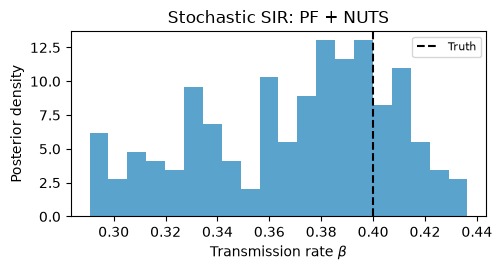

In [67]:
fig, ax = plt.subplots(figsize=(5, 2.8))
ax.hist(stochastic_beta, bins=20, density=True, color="#0072B2", alpha=0.65)
ax.axvline(SIR_TRUE_BETA, color="black", ls="--", label="Truth")
ax.set(
    xlabel=r"Transmission rate $\beta$",
    ylabel="Posterior density",
    title="Stochastic SIR: PF + NUTS",
)
ax.legend(fontsize=8)
fig.tight_layout()
plt.show()

### Recover the hidden states by filtering

For each posterior draw of $\beta$, request draws from the filtering distributions $\widehat p(x_k\mid y_{0:k},\beta)$. Here $\beta$ has already been learned from the full dataset: these are filtering distributions **conditional on a fitted parameter**, mixed over its posterior, rather than a fully online parameter-and-state analysis.

`Simulator` around `Filter` records the requested states at `predict_times`. Transform each draw from log-ratio coordinates to $(s,i,r)$ before computing intervals; transforming only a mean would lose uncertainty information.

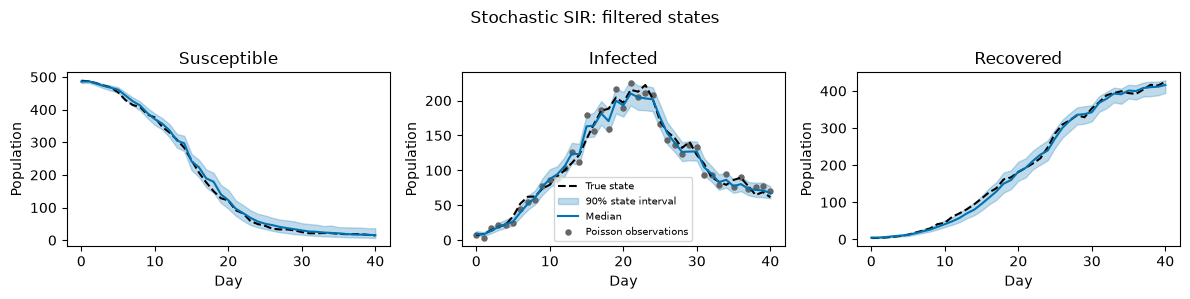

In [61]:
def stochastic_filtering_model(obs_times=None, obs_values=None, predict_times=None):
    with (
        dsx.Simulator(n_simulations=16),
        dsx.Filter(PFConfig(n_particles=512)),
        dsx.Discretizer(),
    ):
        return stochastic_sir_model(obs_times, obs_values, predict_times)


stochastic_parameter_draws = {"beta": stochastic_beta[::4]}
filtered_predictive = Predictive(
    stochastic_filtering_model,
    posterior_samples=stochastic_parameter_draws,
    return_sites=("stochastic_sir_predicted_states",),
)(jr.PRNGKey(96), **stochastic_data, predict_times=stochastic_times)
# (50 parameter draws, 16 state draws, 41 times, 2 log ratios).
filtered_fractions = sir_fractions(
    filtered_predictive["stochastic_sir_predicted_states"]
)
filtered_state_draws = filtered_fractions.reshape(-1, len(stochastic_times), 3)
stochastic_truth = sir_fractions(stochastic_states)
plot_sir_states(
    stochastic_times,
    filtered_state_draws,
    stochastic_times,
    stochastic_truth,
    stochastic_times,
    stochastic_values,
    "Stochastic SIR: filtered states",
)

### Use the full record: smoothing

Filtering at day $k$ uses observations only through day $k$ at a given parameter. Smoothing additionally uses later observations:

$$p(x_k\mid Y)=\int p(x_k\mid Y,\beta)\,p(\beta\mid Y)\,\mathrm d\beta.$$

Replace `Filter` with `Smoother`, then collect `stochastic_sir_smoothed_particles` with `Predictive`. The default particle smoother traces resampled ancestral paths; its equally weighted paths form an empirical smoothing distribution. We retain 16 paths per parameter draw. Finite particle ancestry can lose diversity, especially early in a long record; see the [smoothing tutorial](gentle_intro/09_discrete_smoothing.ipynb) for other algorithms.

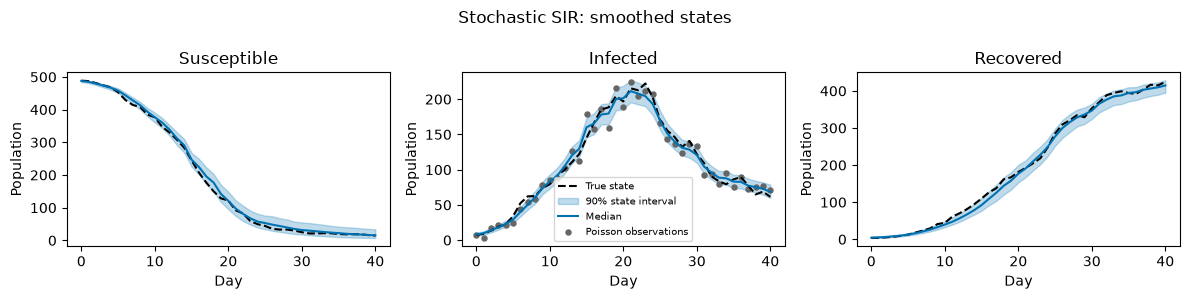

In [62]:
def stochastic_smoothing_model(obs_times=None, obs_values=None):
    with (
        dsx.Smoother(
            PFSmootherConfig(
                n_particles=512,
                pf_n_smoother_particles=16,
                record_smoothed_particles=True,
            )
        ),
        dsx.Discretizer(),
    ):
        return stochastic_sir_model(obs_times, obs_values)


smoothed_predictive = Predictive(
    stochastic_smoothing_model,
    posterior_samples=stochastic_parameter_draws,
    return_sites=("stochastic_sir_smoothed_particles",),
)(jr.PRNGKey(97), **stochastic_data)
# (50 parameter draws, 41 times, 16 smoothed paths, 2 log ratios).
smoothed_fractions = sir_fractions(
    smoothed_predictive["stochastic_sir_smoothed_particles"]
)
smoothed_state_draws = jnp.swapaxes(smoothed_fractions, 1, 2).reshape(
    -1, len(stochastic_times), 3
)
plot_sir_states(
    stochastic_times,
    smoothed_state_draws,
    stochastic_times,
    stochastic_truth,
    stochastic_times,
    stochastic_values,
    "Stochastic SIR: smoothed states",
)

## Where to go next

Start with a model and observation process that reflect your data, then choose state and parameter inference separately. A joint fit using `LatentPathBuilder` is a simple first choice for a small, well-conditioned ODE problem. Filters are useful when explicit paths are hard to explore or process noise creates many latent variables. Compare particle counts, seeds, integration accuracy, and sampler diagnostics before trusting a fit; short one-chain runs here are teaching examples.

Explore the [Gentle Introduction](gentle_intro/00_index.ipynb), [hierarchical models with `dsx.plate`](gentle_intro/08_hierarchical_inference.ipynb), and the [full tutorial collection](../tutorials.md). The [Dynestyx paper](https://arxiv.org/html/2606.16985v1) describes the wider method combinations and their references. Report questions or problems in [GitHub issues](https://github.com/BasisResearch/dynestyx/issues).

### References

- Waxman, D., Batenkov, D., Feser, J., Zane, A., Bingham, E., Marzouk, Y., and Levine, M. E. (2026). [*Dynestyx: A Probabilistic Programming Library for Dynamical Systems*](https://arxiv.org/html/2606.16985v1).
- Andrieu, C., Doucet, A., and Holenstein, R. (2010). [*Particle Markov chain Monte Carlo methods*](https://doi.org/10.1111/j.1467-9868.2009.00736.x). JRSS B, 72(3), 269–342.
- Drovandi, C., Everitt, R. G., Golightly, A., and Prangle, D. (2022). [*Ensemble MCMC: Accelerating Pseudo-Marginal MCMC for State Space Models Using the Ensemble Kalman Filter*](https://doi.org/10.1214/20-BA1251). Bayesian Analysis, 17(1), 223–260.
- Chen, Y., Sanz-Alonso, D., and Willett, R. (2022). [*Autodifferentiable Ensemble Kalman Filters*](https://doi.org/10.1137/21M1434477). SIAM Journal on Mathematics of Data Science, 4(2), 801–833.
- Ścibior, A., and Wood, F. (2021). [*Differentiable Particle Filtering without Modifying the Forward Pass*](https://arxiv.org/abs/2106.10314).

Companion examples: [NumPyro ODE inference](https://num.pyro.ai/en/stable/examples/ode.html), [NumPyro multiple Lotka–Volterra systems](https://num.pyro.ai/en/stable/tutorials/lotka_volterra_multiple.html), and [MFIIDD particle MCMC](https://mfiidd.github.io/mfiidd/sessions/pmcmc.html).